In [215]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from qutip import rand_dm, Qobj, fidelity, rand_ket
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import copy

In [216]:

# Definisco basi qubit
z0 = np.array([[1], [0]])
z1 = np.array([[0], [1]])

# Base X (sovrapposizione)
x0 = (z0 + z1) / np.sqrt(2)
x1 = (z0 - z1) / np.sqrt(2)

# Base Y (sovrapposizione complessa)
y0 = (z0 + 1j*z1) / np.sqrt(2)
y1 = (z0 - 1j*z1) / np.sqrt(2)

basi_singole = [z0, z1, x0, x1, y0, y1]

# Creiamo i proiettori per tutte le combinazioni di basi (36 in totale)
proiettori_numpy = []
for v1 in basi_singole:
    for v2 in basi_singole:
        psi_2q = np.kron(v1, v2) 
        proiettore = psi_2q @ psi_2q.conj().T # Proiettore = |psi><psi|, matrice 4x4, @ è la moltiplicazione di matrici in NumPy
        proiettori_numpy.append(proiettore)

# Generazione dataset di stati a 2 Qubit con rumore di laboratorio
NUM_ESEMPI = 1000
NUM_SHOTS = 1024

X_lista = []
y_lista = []

print(f"Generazione dataset: {NUM_ESEMPI} stati a 2 Qubit...")

for i in range(NUM_ESEMPI):
    # 1. Generiamo i due qubit in modo indipendente (stato separabile)
    psi1 = rand_ket(2).full() # Qubit 1 (vettore 2x1)
    psi2 = rand_ket(2).full() # Qubit 2 (vettore 2x1)
    
    # Uniamoli con il prodotto tensoriale di NumPy per avere uno stato separabile
    psi_2q = np.kron(psi1, psi2) 
    
    # Creiamo la matrice di densità pura
    rho_puro = psi_2q @ psi_2q.conj().T
    
    # 2. Aggiungiamo il rumore
    p_rumore = np.random.uniform(0.0, 0.30)
    rho_matrice = (1 - p_rumore) * rho_puro + p_rumore * (np.eye(4) / 4)
    
    probabilita_teoriche = []
    
    # Misuriamo la probabilità per ognuno dei 36 proiettori
    for P in proiettori_numpy:
        prob = np.real(np.trace(rho_matrice @ P))
        probabilita_teoriche.append(prob)
    
    # Aggiungiamo il rumore di laboratorio (Shot Noise)
    misurazioni_rumorose = np.random.binomial(NUM_SHOTS, probabilita_teoriche) / NUM_SHOTS
    X_lista.append(misurazioni_rumorose)
    
    rho_piatta = np.concatenate([rho_matrice.real.flatten(), rho_matrice.imag.flatten()])
    y_lista.append(rho_piatta)

X = torch.tensor(np.array(X_lista), dtype=torch.float32)
Y = torch.tensor(np.array(y_lista), dtype=torch.float32)

print(f"Finito! Input X: {X.shape} (36 misurazioni). Target y: {Y.shape} (32 elementi complessi).")
print(X[0]) # Prima riga di X (36 misurazioni)
print(Y[0]) # Prima riga di y (32 elementi, prima 16 reali, poi 16 immaginari)

Generazione dataset: 1000 stati a 2 Qubit...
Finito! Input X: torch.Size([1000, 36]) (36 misurazioni). Target y: torch.Size([1000, 32]) (32 elementi complessi).
tensor([0.2344, 0.0361, 0.0586, 0.2412, 0.1904, 0.1035, 0.6201, 0.1055, 0.1494,
        0.5654, 0.4580, 0.2334, 0.5283, 0.0898, 0.1377, 0.4863, 0.4062, 0.2227,
        0.3301, 0.0410, 0.0791, 0.2900, 0.2500, 0.1230, 0.8047, 0.1191, 0.1826,
        0.7588, 0.6133, 0.3096, 0.0645, 0.0068, 0.0117, 0.0498, 0.0498, 0.0215])
tensor([ 0.2546, -0.0868,  0.1120, -0.1081, -0.0868,  0.0383,  0.0317,  0.0168,
         0.1120,  0.0317,  0.6148, -0.2096, -0.1081,  0.0168, -0.2096,  0.0924,
         0.0000, -0.0469, -0.3794,  0.1087,  0.0469,  0.0000,  0.1500, -0.0570,
         0.3794, -0.1500,  0.0000, -0.1132, -0.1087,  0.0570,  0.1132,  0.0000])


In [217]:
def calcola_fidelity_modello(y_vero_flat, y_predetto_flat):
    """Calcola la Fidelity tra il target (vero) e l'output della rete (predetto)"""
    # Ricostruiamo i numeri complessi 
    vero_complex = y_vero_flat[:16] + 1j * y_vero_flat[16:]
    pred_complex = y_predetto_flat[:16] + 1j * y_predetto_flat[16:]
    
    # Riformattiamo a griglia 4x4 e diciamo a QuTiP che sono 2 qubit
    rho_vera = Qobj(vero_complex.reshape(4, 4), dims=[[2, 2], [2, 2]])
    rho_pred = Qobj(pred_complex.reshape(4, 4), dims=[[2, 2], [2, 2]])
    
    return fidelity(rho_vera, rho_pred)

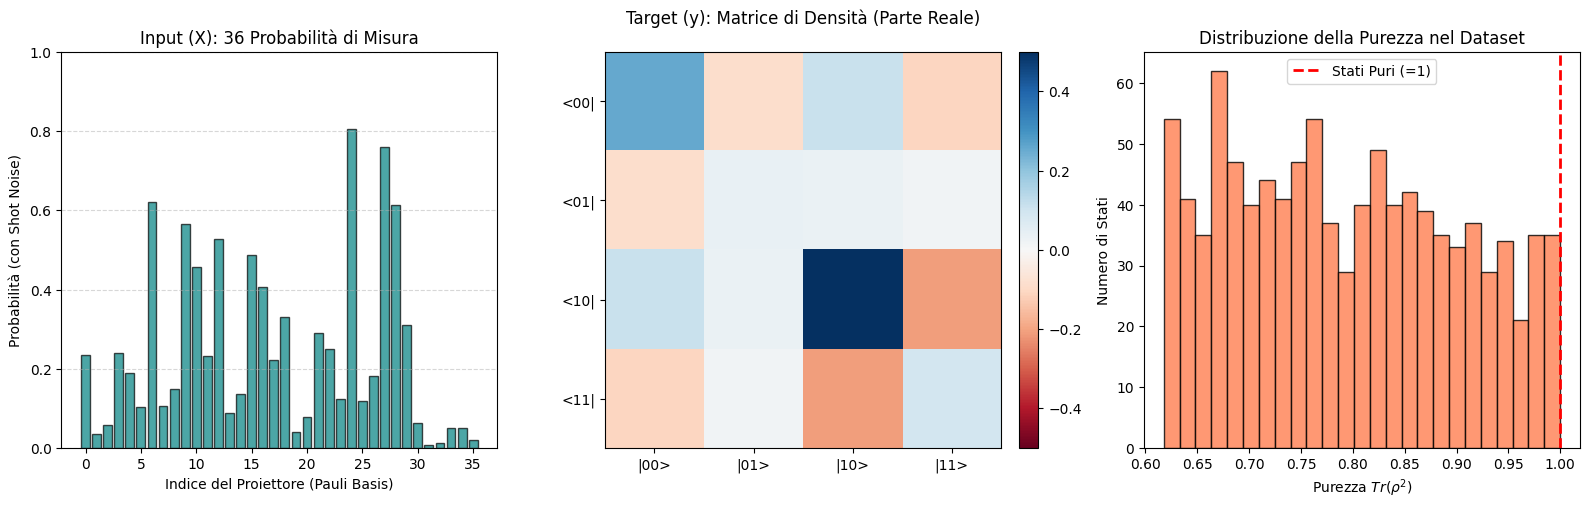

In [233]:
# Prendiamo il primo stato generato (indice 0) per i grafici 1 e 2
indice = 0
misurazioni = X[indice].numpy() # 36 misurazioni rumorose (input)
matrice_flat = Y[indice].numpy() # 32 elementi (target), prima 16 reali, poi 16 immaginari

# Ricostruiamo la matrice 4x4 (Reale e Immaginaria)
rho_real = matrice_flat[:16].reshape(4, 4)
rho_imag = matrice_flat[16:].reshape(4, 4)

fig = plt.figure(figsize=(16, 5))

ax1 = fig.add_subplot(1, 3, 1)
ax1.bar(range(36), misurazioni, color='teal', alpha=0.7, edgecolor='black')
ax1.set_title("Input (X): 36 Probabilità di Misura", fontsize=12)
ax1.set_xlabel("Indice del Proiettore (Pauli Basis)")
ax1.set_ylabel("Probabilità (con Shot Noise)")
ax1.set_ylim(0, 1)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

ax2 = fig.add_subplot(1, 3, 2)
cax = ax2.matshow(rho_real, cmap='RdBu', vmin=-0.5, vmax=0.5)
ax2.set_title("Target (y): Matrice di Densità (Parte Reale)", fontsize=12, pad=20)
ax2.set_xticks(range(4))
ax2.set_yticks(range(4))
ax2.set_xticklabels(['|00>', '|01>', '|10>', '|11>'])
ax2.set_yticklabels(['<00|', '<01|', '<10|', '<11|'])
ax2.xaxis.set_ticks_position('bottom')
fig.colorbar(cax, ax=ax2, fraction=0.046, pad=0.04)

purezze = []
for y in Y.numpy():
    c_mat = (y[:16] + 1j * y[16:]).reshape(4, 4)
    purezza = np.real(np.trace(c_mat @ c_mat))
    purezze.append(purezza)

ax3 = fig.add_subplot(1, 3, 3)
ax3.hist(purezze, bins=25, color='coral', edgecolor='black', alpha=0.8)
ax3.set_title("Distribuzione della Purezza nel Dataset", fontsize=12)
ax3.set_xlabel(r"Purezza $Tr(\rho^2)$")
ax3.set_ylabel("Numero di Stati")
ax3.axvline(1.0, color='red', linestyle='dashed', linewidth=2, label='Stati Puri (=1)')
ax3.legend()

plt.tight_layout()
plt.savefig("Immagini/dataset_qst.pdf", format='pdf')
plt.show()

In [219]:
class DensityMatrixLayer(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x): # x è l'output intermedio generato dalla rete neurale standard
        # x ha dimensione (batch_size, 16)
        batch_size = x.shape[0]
        
        # Inizializziamo T come matrice complessa 4x4
        T = torch.zeros((batch_size, 4, 4), dtype=torch.complex64) 
        
        # Riempiamo la diagonale (Reale e strettamente positiva)
        T[:, 0, 0] = x[:, 0] + 0j
        T[:, 1, 1] = x[:, 1] + 0j
        T[:, 2, 2] = x[:, 2] + 0j
        T[:, 3, 3] = x[:, 3] + 0j
        
        # Riempiamo la parte triangolare inferiore (Complessa)
        T[:, 1, 0] = x[:, 4] + 1j * x[:, 5]
        T[:, 2, 0] = x[:, 6] + 1j * x[:, 7]
        T[:, 2, 1] = x[:, 8] + 1j * x[:, 9]
        T[:, 3, 0] = x[:, 10] + 1j * x[:, 11]
        T[:, 3, 1] = x[:, 12] + 1j * x[:, 13]
        T[:, 3, 2] = x[:, 14] + 1j * x[:, 15]

        # rho = T * T_dagger (Questa operazione la rende Hermitiana e Semi-definita Positiva)
        T_dagger = T.conj().transpose(1, 2) # decomposizione di Cholesky
        rho = torch.bmm(T, T_dagger)
        
        # Normalizziamo dividendo per la traccia, in modo che Tr(rho) = 1
        traccia = torch.diagonal(rho, dim1=-2, dim2=-1).sum(-1, keepdim=True).unsqueeze(-1)
        rho_norm = rho / traccia
        
        return rho_norm

# Se questa matrice di densità $\rho$ fosse vera, cosa vedrei nei miei strumenti di laboratorio?
class ExpectationLayer(nn.Module):
    def __init__(self, proiettori_numpy):
        super().__init__()
        # Salviamo i proiettori come tensore fisso di PyTorch
        self.proiettori = torch.tensor(np.array(proiettori_numpy), dtype=torch.complex64)

    def forward(self, rho):
        # Calcoliamo le 36 probabilità usando l'equazione vettorizzata di Tr(rho * P)
        # einsum fa esattamente la moltiplicazione matriciale e la traccia in un colpo solo
        misurazioni_generate = torch.einsum('bij,nji->bn', rho, self.proiettori).real
        return misurazioni_generate

In [220]:
class EarlyStopping:
    def __init__(self, patience=30, min_delta=0.0):
        self.patience = patience # Quante epoche aspettare senza miglioramenti
        self.min_delta = min_delta # Miglioramento minimo per essere considerato "valido"
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False
        self.best_model_G_weights = None # Qui salveremo la rete migliore

    def __call__(self, val_loss, generatore):
        # Se troviamo un nuovo minimo...
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            # Copiamo e mettiamo in cassaforte i pesi attuali del generatore
            self.best_model_G_weights = copy.deepcopy(generatore.state_dict())
        else:
            # Altrimenti aumentiamo il contatore
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

In [221]:
class Generator(nn.Module):
    def __init__(self, proiettori_numpy):
        super().__init__()
        # La rete neurale "standard"
        self.net = nn.Sequential(
            nn.Linear(36, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 16) 
        )
        
        # Assegniamo i layer fisici
        self.density_matrix_layer = DensityMatrixLayer()
        self.expectation_layer = ExpectationLayer(proiettori_numpy)

    def forward(self, x):
        # Dai 36 input, la rete deduce 16 pesi astratti
        parametri_t = self.net(x)
        
        # Il layer fisico forza i pesi a diventare una matrice di densità perfetta
        rho_generata = self.density_matrix_layer(parametri_t)
        
        # Il secondo layer fisico calcola le 36 misurazioni teoriche di questa nuova matrice
        misurazioni_generate = self.expectation_layer(rho_generata)
        
        return rho_generata, misurazioni_generate


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        # Nel paper, il discriminatore è "condizionato":
        # Valuta i dati in base alle statistiche originali.
        # Input = 36 probabilità originali + 36 probabilità da valutare = 72
        self.net = nn.Sequential(
            nn.Linear(72, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 1),
            nn.Sigmoid() # Restituisce 1 (Vero) o 0 (Falso)
        )

    def forward(self, misurazioni_vere_condizione, misurazioni_da_valutare):
        # Uniamo le due serie di 36 misurazioni
        x = torch.cat([misurazioni_vere_condizione, misurazioni_da_valutare], dim=1)
        return self.net(x)

# Inizializziamo i modelli usando la lista "proiettori_numpy" che avevamo generato prima
generatore = Generator(proiettori_numpy)
discriminatore = Discriminator()

print("QST-CGAN inizializzata con successo!")

QST-CGAN inizializzata con successo!


In [222]:
X_train, X_temp, y_train, y_temp = train_test_split(X, Y, test_size=0.30, random_state=42)

# SECONDA DIVISIONE: Dividiamo il blocco temporaneo esattamente a metà (test_size=0.50).
# Il 50% del 30% equivale esattamente al 15% dei dati originali.
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f"Dati di Train (70%):      {X_train.shape[0]} campioni")
print(f"Dati di Validation (15%): {X_val.shape[0]} campioni")
print(f"Dati di Test (15%):       {X_test.shape[0]} campioni")

# Creiamo i Dataset per tutti e tre i gruppi
dataset_train = TensorDataset(X_train, y_train)
dataset_val = TensorDataset(X_val, y_val)
dataset_test = TensorDataset(X_test, y_test)

# Creiamo i DataLoader
dataloader_train = DataLoader(dataset_train, batch_size=50, shuffle=True)
dataloader_val = DataLoader(dataset_val, batch_size=50, shuffle=False)
dataloader_test = DataLoader(dataset_test, batch_size=50, shuffle=False)

# --- INIZIALIZZAZIONE ---
opt_G = optim.Adam(generatore.parameters(), lr=0.0002, betas=(0.5, 0.999))
opt_D = optim.Adam(discriminatore.parameters(), lr=0.00005, betas=(0.5, 0.999))
criterio_gan = nn.BCELoss()
expectation_layer_target = ExpectationLayer(proiettori_numpy)

early_stopping = EarlyStopping(patience=30, min_delta=0.0001)
EPOCHS = 1000

# --- 1. PREPARIAMO LE LISTE PER SALVARE LA STORIA ---
storia_loss_D = []
storia_loss_G = []
storia_errore_train = []
storia_errore_val = []
storia_fidelity_val = [] 
storia_fidelity_std = []

print("Inizio dell'addestramento avversario...")

for epoca in range(EPOCHS):
    
    # Variabili per accumulare i valori dell'epoca corrente
    loss_D_epoca = 0.0
    loss_G_epoca = 0.0
    errore_train_epoca = 0.0
    
    # Mettiamo le reti in modalità addestramento
    generatore.train()
    discriminatore.train()
    
    # --- CICLO DI TRAIN ---
    for batch_X, batch_y in dataloader_train:
    
        # Ricostruiamo le matrici target vere
        rho_vera_complex = batch_y[:, :16] + 1j * batch_y[:, 16:]
        rho_vera = rho_vera_complex.reshape(-1, 4, 4)
        misurazioni_vere_pulite = expectation_layer_target(rho_vera)

        etichette_vere = torch.ones((batch_X.size(0), 1))
        etichette_false = torch.zeros((batch_X.size(0), 1))

        # --- ADDESTRAMENTO DISCRIMINATORE ---
        opt_D.zero_grad()
        
        pred_vero = discriminatore(batch_X, misurazioni_vere_pulite)
        loss_D_vero = criterio_gan(pred_vero, etichette_vere)

        rho_gen, misurazioni_gen = generatore(batch_X)
        pred_falso = discriminatore(batch_X, misurazioni_gen.detach())
        loss_D_falso = criterio_gan(pred_falso, etichette_false)

        loss_D = (loss_D_vero + loss_D_falso) / 2
        loss_D.backward()
        opt_D.step()

        # --- ADDESTRAMENTO GENERATORE ---
        opt_G.zero_grad() 
        rho_gen, misurazioni_gen = generatore(batch_X)
        pred_inganno = discriminatore(batch_X, misurazioni_gen)
        
        loss_G = criterio_gan(pred_inganno, etichette_vere)
        loss_G.backward()
        opt_G.step()
        
        # --- CALCOLO ERRORE DI RICOSTRUZIONE (Fisico) ---
        # Usiamo il Mean Squared Error calcolato sul modulo quadro della differenza
        # tra la matrice generata e quella vera.
        errore_fisico = torch.mean(torch.abs(rho_vera - rho_gen)**2)
        
        # Accumuliamo le statistiche per fare la media a fine epoca
        loss_D_epoca += loss_D.item()
        loss_G_epoca += loss_G.item()
        errore_train_epoca += errore_fisico.item()

    # Salviamo le medie del Train per questa epoca
    storia_loss_D.append(loss_D_epoca / len(dataloader_train))
    storia_loss_G.append(loss_G_epoca / len(dataloader_train))
    storia_errore_train.append(errore_train_epoca / len(dataloader_train))
    
    # --- 2. CICLO DI TEST / VALIDAZIONE ---
    # Per valutare la generalizzazione senza aggiornare i pesi
    generatore.eval()
    errore_val_epoca = 0.0
    fidelities_epoca = [] # <--- Nuova lista per l'epoca corrente
    
    with torch.no_grad(): 
        for batch_X_val, batch_y_val in dataloader_val:
            # Ricostruisci target
            rho_vera_complex_v = batch_y_val[:, :16] + 1j * batch_y_val[:, 16:]
            rho_vera_v = rho_vera_complex_v.reshape(-1, 4, 4)
            
            # Genera predizione
            rho_gen_v, _ = generatore(batch_X_val)
            
            # Calcolo MSE
            errore_fisico_v = torch.mean(torch.abs(rho_vera_v - rho_gen_v)**2)
            errore_val_epoca += errore_fisico_v.item()
            
            # --- NUOVO: Calcolo Fidelity ---
            # Per evitare cicli infiniti, estraiamo i numpy array del batch
            for k in range(len(batch_y_val)):
                y_vero_f = batch_y_val[k].numpy()
                rho_gen_matrice = rho_gen_v[k].numpy()
                y_pred_f = np.concatenate([rho_gen_matrice.real.flatten(), rho_gen_matrice.imag.flatten()])
                
                # Calcola e salva
                fid = calcola_fidelity_modello(y_vero_f, y_pred_f)
                fidelities_epoca.append(fid)
            
    storia_errore_val.append(errore_val_epoca / len(dataloader_val))
    storia_fidelity_val.append(np.mean(fidelities_epoca))
    storia_fidelity_std.append(np.std(fidelities_epoca))

    early_stopping(errore_val_epoca / len(dataloader_val), generatore)
    
    if early_stopping.early_stop:
        print(f"\n--- STOP AUTOMATICO ALL'EPOCA {epoca+1} ---")
        print("L'errore non scende più. Addestramento fermato per evitare overfitting.")
        break
        
    # --- STAMPA PROGRESSI ---
    if (epoca + 1) % 25 == 0:
        print(f"Epoca {epoca+1:3d}/{EPOCHS} | Loss D: {storia_loss_D[-1]:.4f} | Loss G: {storia_loss_G[-1]:.4f} | Err Train: {storia_errore_train[-1]:.4f} | Err Validation: {storia_errore_val[-1]:.4f}")

generatore.load_state_dict(early_stopping.best_model_G_weights)
print("Pesi ottimali ripristinati con successo!")
print("Addestramento completato con successo!")

# --- 3. SALVATAGGIO DEI DATI ---
# Salviamo le metriche in un dizionario usando torch.save (metodo raccomandato per PyTorch)
dati_grafici = {
    'loss_D': storia_loss_D,
    'loss_G': storia_loss_G,
    'err_train': storia_errore_train,
    'err_val': storia_errore_val,
    'fidelity_val': storia_fidelity_val,
    'fidelity_std': storia_fidelity_std
}
torch.save(dati_grafici, 'storia_addestramento.pt')
print("Dati per i grafici salvati in 'storia_addestramento.pt'")

Dati di Train (70%):      700 campioni
Dati di Validation (15%): 150 campioni
Dati di Test (15%):       150 campioni
Inizio dell'addestramento avversario...


Epoca  25/1000 | Loss D: 0.6908 | Loss G: 0.6905 | Err Train: 0.0474 | Err Validation: 0.0528
Epoca  50/1000 | Loss D: 0.6803 | Loss G: 0.7041 | Err Train: 0.0679 | Err Validation: 0.0612
Epoca  75/1000 | Loss D: 0.6830 | Loss G: 0.6963 | Err Train: 0.0573 | Err Validation: 0.0629
Epoca 100/1000 | Loss D: 0.6948 | Loss G: 0.6912 | Err Train: 0.0033 | Err Validation: 0.0034
Epoca 125/1000 | Loss D: 0.6936 | Loss G: 0.6937 | Err Train: 0.0025 | Err Validation: 0.0024
Epoca 150/1000 | Loss D: 0.6932 | Loss G: 0.6935 | Err Train: 0.0016 | Err Validation: 0.0018
Epoca 175/1000 | Loss D: 0.6931 | Loss G: 0.6935 | Err Train: 0.0013 | Err Validation: 0.0015
Epoca 200/1000 | Loss D: 0.6931 | Loss G: 0.6933 | Err Train: 0.0011 | Err Validation: 0.0013
Epoca 225/1000 | Loss D: 0.6931 | Loss G: 0.6933 | Err Train: 0.0009 | Err Validation: 0.0011
Epoca 250/1000 | Loss D: 0.6931 | Loss G: 0.6931 | Err Train: 0.0008 | Err Validation: 0.0010
Epoca 275/1000 | Loss D: 0.6931 | Loss G: 0.6932 | Err Train

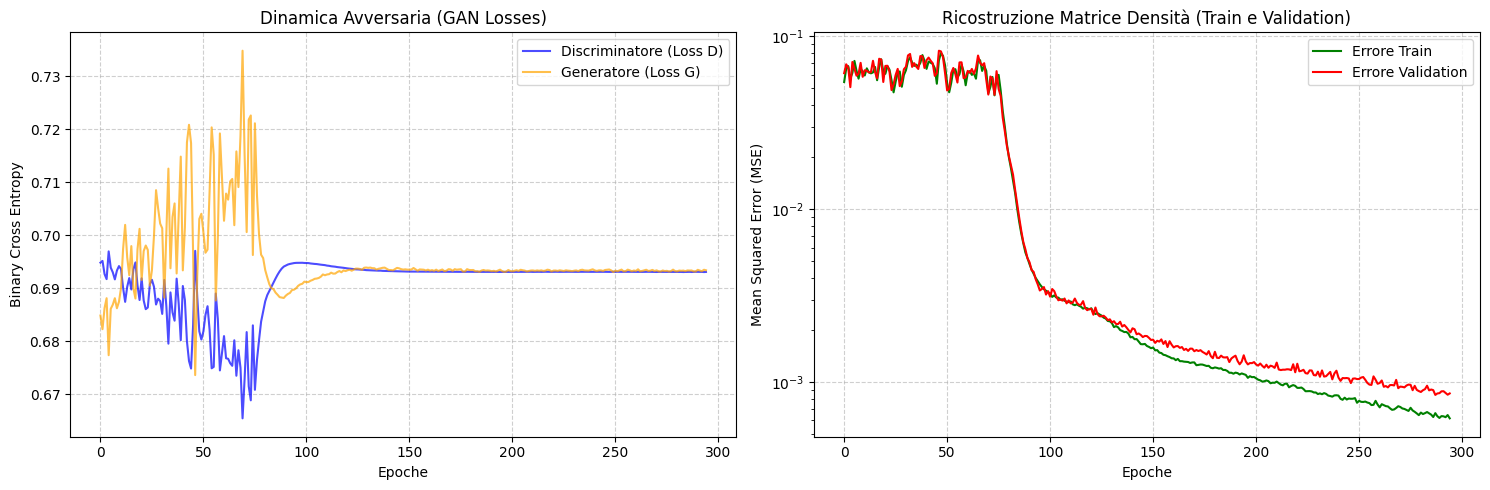

In [234]:
# Carica i dati salvati
storia = torch.load('storia_addestramento.pt', weights_only=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# --- GRAFICO 1: Loss della GAN ---
ax1.plot(storia['loss_D'], label='Discriminatore (Loss D)', color='blue', alpha=0.7)
ax1.plot(storia['loss_G'], label='Generatore (Loss G)', color='orange', alpha=0.7)
ax1.set_title("Dinamica Avversaria (GAN Losses)")
ax1.set_xlabel("Epoche")
ax1.set_ylabel("Binary Cross Entropy")
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# --- GRAFICO 2: Errore di Train e Validation ---
ax2.plot(storia['err_train'], label='Errore Train', color='green')
ax2.plot(storia['err_val'], label='Errore Validation', color='red')
ax2.set_title("Ricostruzione Matrice Densità (Train e Validation)")
ax2.set_xlabel("Epoche")
ax2.set_ylabel("Mean Squared Error (MSE)")
ax2.set_yscale('log') 
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("Immagini/storia_addestramento_qst.pdf", format='pdf')
plt.show()

In [224]:
# Mettiamo la rete in modalità "valutazione"
generatore.eval()

# Usiamo i dati di TEST!
with torch.no_grad(): 
    # Generiamo tutte le matrici per il test set
    rho_previste_test, _ = generatore(X_test)

fidelities_test = []

# Calcoliamo la Fidelity per ogni singolo esempio nel test set
print("Calcolo della Fidelity sul Test Set in corso...")

for i in range(len(y_test)):
    # Dati veri (dal test set)
    y_vero_flat = y_test[i].numpy()
    
    # Dati predetti
    rho_prevista_matrice = rho_previste_test[i].numpy()
    y_predetto_flat = np.concatenate([
        rho_prevista_matrice.real.flatten(), 
        rho_prevista_matrice.imag.flatten()
    ])
    
    # Calcolo
    fedelta = calcola_fidelity_modello(y_vero_flat, y_predetto_flat)
    fidelities_test.append(fedelta)

fidelity_media = np.mean(fidelities_test)
fidelity_std = np.std(fidelities_test)

print("-" * 40)
print(f"Fidelity Media (Test Set): {fidelity_media:.4f} ± {fidelity_std:.4f}")
print("-" * 40)

Calcolo della Fidelity sul Test Set in corso...
----------------------------------------
Fidelity Media (Test Set): 0.9857 ± 0.0071
----------------------------------------


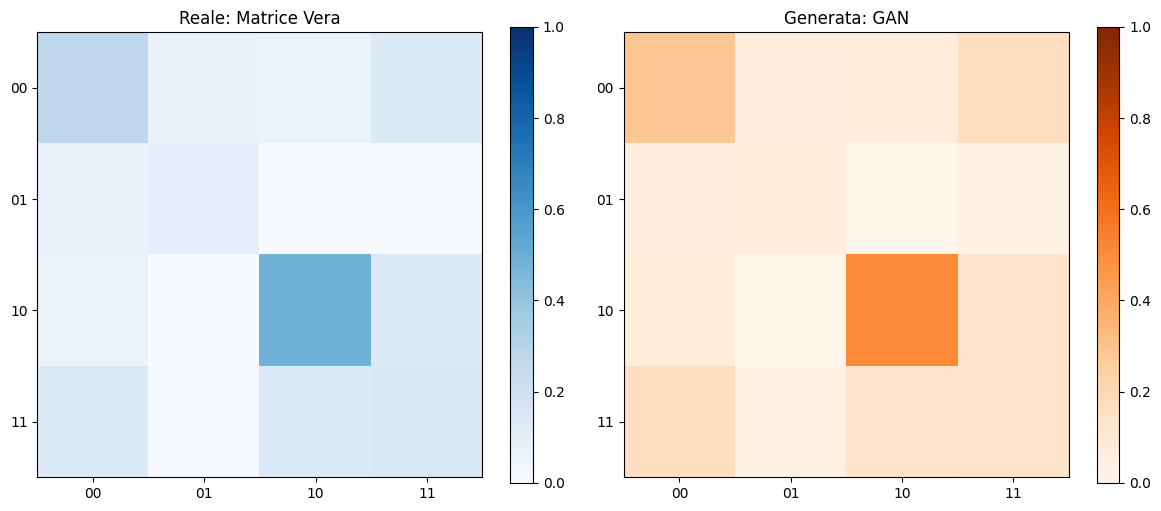

In [235]:
def visualizza_heatmap_2d(y_vero_tensor, rho_gen_tensor, indice=0):
    y_vero_flat = y_vero_tensor[indice].numpy()
    rho_gen_complex = rho_gen_tensor[indice].numpy()
    
    vera_real = (y_vero_flat[:16] + 1j * y_vero_flat[16:]).reshape(4, 4).real
    gen_real = rho_gen_complex.real
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    im1 = ax1.imshow(vera_real, cmap='Blues', vmin=0, vmax=1)
    ax1.set_title("Reale: Matrice Vera")
    ax1.set_xticks(np.arange(4)); ax1.set_yticks(np.arange(4))
    ax1.set_xticklabels(['00', '01', '10', '11']); ax1.set_yticklabels(['00', '01', '10', '11'])
    fig.colorbar(im1, ax=ax1)
    
    im2 = ax2.imshow(gen_real, cmap='Oranges', vmin=0, vmax=1)
    ax2.set_title("Generata: GAN")
    ax2.set_xticks(np.arange(4)); ax2.set_yticks(np.arange(4))
    ax2.set_xticklabels(['00', '01', '10', '11']); ax2.set_yticklabels(['00', '01', '10', '11'])
    fig.colorbar(im2, ax=ax2)
    
    plt.tight_layout()
    plt.savefig(f"Immagini/heatmap_confronto_{indice}.pdf", format='pdf')
    plt.show()

# ESEMPIO D'USO (Assicurati di aver calcolato prima rho_previste_test)
visualizza_heatmap_2d(y_test, rho_previste_test, indice=5)

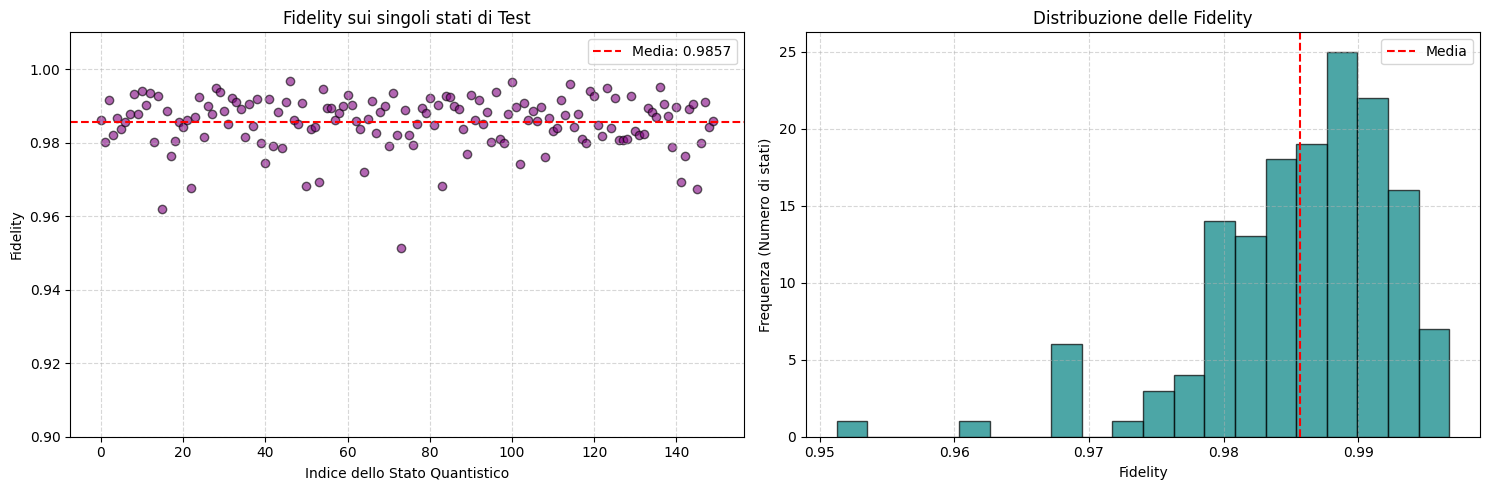

In [236]:
# Assicuriamoci che fidelities_test sia un array numpy
fidelities_array = np.array(fidelities_test)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# --- Grafico A: Scatter Plot (Fidelity per ogni stato) ---
ax1.scatter(range(len(fidelities_array)), fidelities_array, color='purple', alpha=0.6, edgecolors='k')
ax1.axhline(fidelity_media, color='red', linestyle='--', label=f'Media: {fidelity_media:.4f}')
ax1.set_title("Fidelity sui singoli stati di Test")
ax1.set_xlabel("Indice dello Stato Quantistico")
ax1.set_ylabel("Fidelity")
ax1.set_ylim(0.90, 1.01) # Mettiamo un limite logico per la Fidelity
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend()

# --- Grafico B: Istogramma (Distribuzione) ---
ax2.hist(fidelities_array, bins=20, color='teal', alpha=0.7, edgecolor='black')
ax2.axvline(fidelity_media, color='red', linestyle='--', label='Media')
ax2.set_title("Distribuzione delle Fidelity")
ax2.set_xlabel("Fidelity")
ax2.set_ylabel("Frequenza (Numero di stati)")
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend()

plt.tight_layout()
plt.savefig("Immagini/fidelity_test_set.pdf", format='pdf')
plt.show()

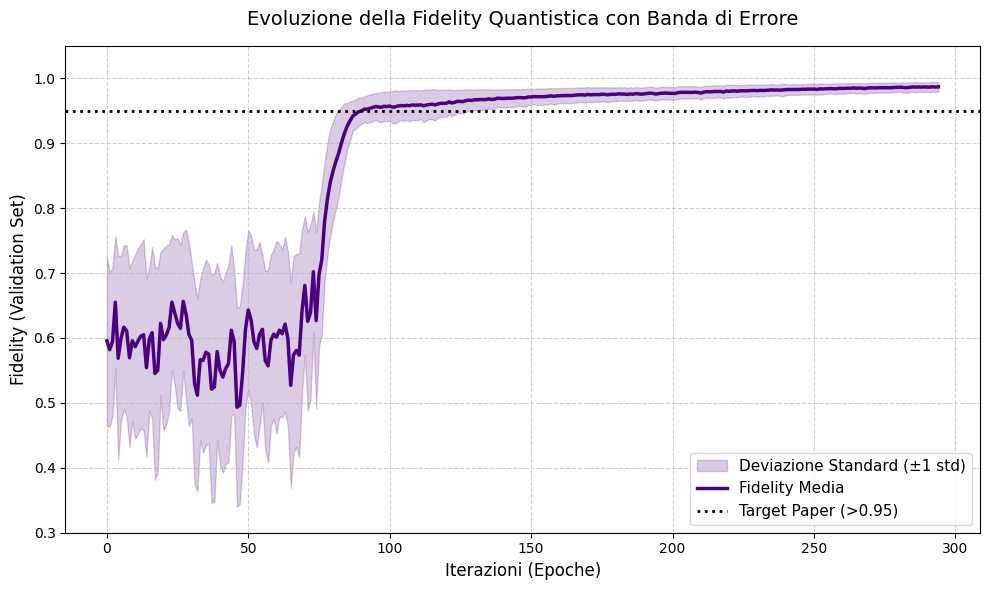

In [237]:
# Convertiamo le liste in array numpy per fare le somme/sottrazioni facilmente
epoche = np.arange(len(storia_fidelity_val))
medie = np.array(storia_fidelity_val)
dev_std = np.array(storia_fidelity_std)

plt.figure(figsize=(10, 6))

# 1. Disegniamo l'alone della Deviazione Standard (prima della linea, così sta "sotto")
plt.fill_between(epoche, 
                 medie - dev_std, 
                 medie + dev_std, 
                 color='indigo', alpha=0.2, # alpha=0.2 lo rende semi-trasparente
                 label='Deviazione Standard (±1 std)')

# 2. Disegniamo la linea principale (Media)
plt.plot(epoche, medie, color='indigo', linewidth=2.5, label='Fidelity Media')

# 3. Grafica e abbellimenti
plt.title("Evoluzione della Fidelity Quantistica con Banda di Errore", fontsize=14, pad=15)
plt.xlabel("Iterazioni (Epoche)", fontsize=12)
plt.ylabel("Fidelity (Validation Set)", fontsize=12)
plt.ylim(0.3, 1.05) # Mantiene la scala corretta
plt.grid(True, linestyle='--', alpha=0.6)

# Linea del target (0.95)
plt.axhline(0.95, color='black', linestyle=':', linewidth=2, label='Target Paper (>0.95)')

# Mettiamo la legenda in basso a destra per non coprire la curva iniziale
plt.legend(loc='lower right', fontsize=11)

plt.tight_layout()
plt.savefig("Immagini/fidelity_con_banda_errore.pdf", format='pdf')
plt.show()

Calcolo della robustezza al rumore in corso...
Rumore: 0.00 | Fidelity Media: 0.9857
Rumore: 0.01 | Fidelity Media: 0.9852
Rumore: 0.02 | Fidelity Media: 0.9839
Rumore: 0.05 | Fidelity Media: 0.9765
Rumore: 0.10 | Fidelity Media: 0.9480
Rumore: 0.15 | Fidelity Media: 0.9046
Rumore: 0.20 | Fidelity Media: 0.8623


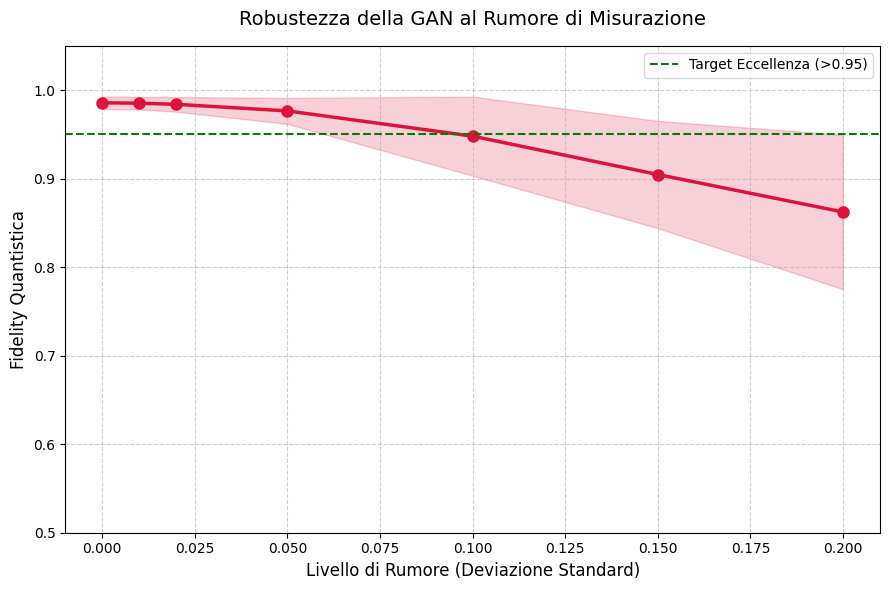

In [238]:
# Definiamo i livelli di rumore (Deviazione standard della Gaussiana)
# Da 0 (dati perfetti) a 0.2 (dati con il 20% di rumore fortissimo)
livelli_rumore = [0.0, 0.01, 0.02, 0.05, 0.10, 0.15, 0.20]
fidelities_medie_rumore = []
fidelities_std_rumore = []

generatore.eval()
print("Calcolo della robustezza al rumore in corso...")

for rumore in livelli_rumore:
    # Aggiungiamo rumore gaussiano ai dati in ingresso
    rumore_tensor = torch.randn_like(X_test) * rumore
    X_test_rumoroso = X_test + rumore_tensor
    
    with torch.no_grad():
        rho_previste_rumorose, _ = generatore(X_test_rumoroso)
        
    fidelities_correnti = []
    
    # Calcoliamo la fidelity per questo livello di rumore
    for i in range(len(y_test)):
        y_vero_flat = y_test[i].numpy()
        rho_gen_matrice = rho_previste_rumorose[i].numpy()
        y_predetto_flat = np.concatenate([rho_gen_matrice.real.flatten(), rho_gen_matrice.imag.flatten()])
        
        fid = calcola_fidelity_modello(y_vero_flat, y_predetto_flat)
        fidelities_correnti.append(fid)
        
    fidelities_medie_rumore.append(np.mean(fidelities_correnti))
    fidelities_std_rumore.append(np.std(fidelities_correnti))
    print(f"Rumore: {rumore:.2f} | Fidelity Media: {fidelities_medie_rumore[-1]:.4f}")

# --- DISEGNIAMO IL GRAFICO ---
plt.figure(figsize=(9, 6))
epoche_np = np.array(livelli_rumore)
medie_np = np.array(fidelities_medie_rumore)
std_np = np.array(fidelities_std_rumore)

plt.fill_between(epoche_np, medie_np - std_np, medie_np + std_np, color='crimson', alpha=0.2)
plt.plot(epoche_np, medie_np, marker='o', color='crimson', linewidth=2.5, markersize=8)

plt.title("Robustezza della GAN al Rumore di Misurazione", fontsize=14, pad=15)
plt.xlabel("Livello di Rumore (Deviazione Standard)", fontsize=12)
plt.ylabel("Fidelity Quantistica", fontsize=12)
plt.ylim(0.5, 1.05)
plt.axhline(0.95, color='green', linestyle='--', label='Target Eccellenza (>0.95)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig("Immagini/robustezza_rumore.pdf", format='pdf')
plt.show()

Calcolo delle purezze in corso...


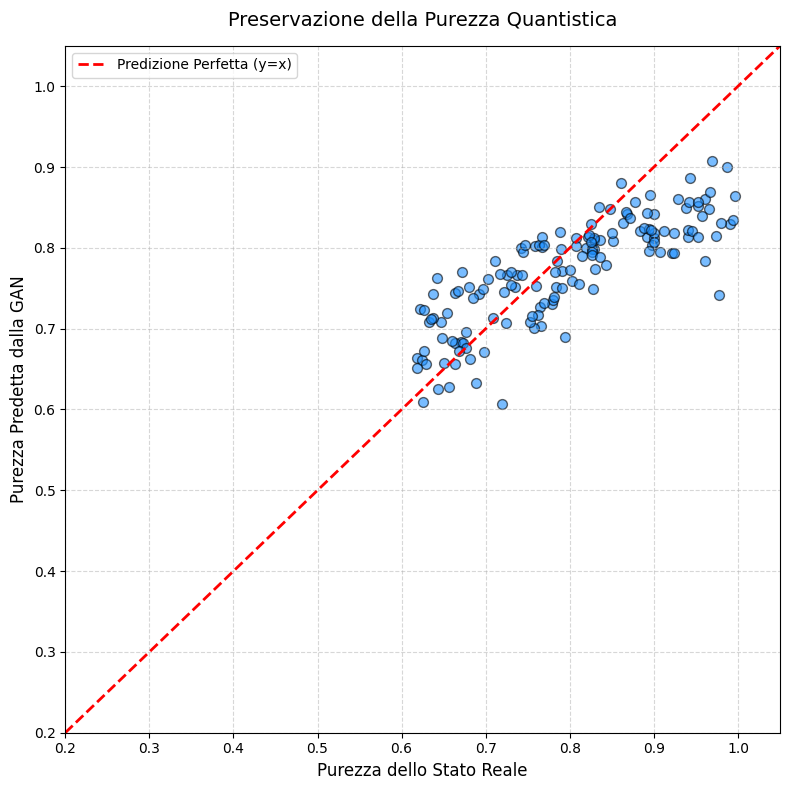

In [239]:
def calcola_purezza(rho_matrice):
    # La purezza è la traccia del quadrato della matrice densità
    return np.real(np.trace(np.dot(rho_matrice, rho_matrice)))

purezze_vere = []
purezze_generate = []

print("Calcolo delle purezze in corso...")

generatore.eval()
with torch.no_grad():
    rho_previste_test, _ = generatore(X_test)

for i in range(len(y_test)):
    # 1. Ricostruiamo e calcoliamo la purezza della matrice VERA
    y_vero_flat = y_test[i].numpy()
    rho_vera_complex = (y_vero_flat[:16] + 1j * y_vero_flat[16:]).reshape(4, 4)
    pur_vera = calcola_purezza(rho_vera_complex)
    purezze_vere.append(pur_vera)
    
    # 2. Calcoliamo la purezza della matrice GENERATA dalla GAN
    rho_gen_complex = rho_previste_test[i].numpy()
    pur_gen = calcola_purezza(rho_gen_complex)
    purezze_generate.append(pur_gen)

# --- DISEGNIAMO IL GRAFICO ---
plt.figure(figsize=(8, 8)) # Quadrato perfetto per far risaltare la diagonale

# Scatter plot dei punti
plt.scatter(purezze_vere, purezze_generate, color='dodgerblue', alpha=0.6, edgecolors='k', s=50)

# Disegniamo la bisettrice ideale (y = x)
# Se la rete è perfetta, tutti i punti cadranno esattamente su questa linea
plt.plot([0.2, 1.05], [0.2, 1.05], color='red', linestyle='--', linewidth=2, label='Predizione Perfetta (y=x)')

plt.title("Preservazione della Purezza Quantistica", fontsize=14, pad=15)
plt.xlabel("Purezza dello Stato Reale", fontsize=12)
plt.ylabel("Purezza Predetta dalla GAN", fontsize=12)
plt.xlim(0.2, 1.05)
plt.ylim(0.2, 1.05)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig("Immagini/purezza_confronto.pdf", format='pdf')
plt.show()